In [1]:
import time
import os
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import corner
from scipy import optimize
from simple_pe.param_est.pe import SimplePESamples
from simple_pe.param_est.filter import matched_filter_network
from simple_pe.waveforms import waveform, waveform_modes, eccentric
from simple_pe import io
from pesummary.io import read
from pesummary.utils.samples_dict import SamplesDict
from pesummary.gw.conversions.mass import q_from_eta, component_masses_from_mchirp_q

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

lal.MSUN_SI != Msun


In [16]:
# Load run files
dir_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_2/outdir/output'
inj_path = os.path.join(dir_path, 'converted_injection_parameters.json')
with open(inj_path, 'r') as f:
    all_inj_params = json.load(f)
peak_path = os.path.join(dir_path, 'peak_parameters.json')
with open(peak_path, 'r') as f:
    all_peak_params = json.load(f)
metric_path = os.path.join(dir_path, 'analysis_metric.pkl')
with open(metric_path, 'rb') as f:
    analysis_metric = pickle.load(f)
samples_path = os.path.join(dir_path, 'posterior_samples.dat')
samples = SimplePESamples(read(samples_path).samples_dict)

# Load psds
asds = {'H1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'L1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'V1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/avirgo_O4high_NEW.txt'}
psds = io.load_psd_from_file([], asds, 1/32, 15, 2048)

# Load data
trig_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/trigger_parameters.json'
strain_paths = {'H1': os.path.join(dir_path, 'H1-INJECTION.gwf'),
                'L1': os.path.join(dir_path, 'L1-INJECTION.gwf'),
                'V1': os.path.join(dir_path, 'V1-INJECTION.gwf')}
trigger_parameters = io.load_trigger_parameters_from_file(trig_path, 'TEOBResumS-Dali')
_, data = io.load_strain_data_from_file(
    trigger_parameters, strain_paths, {'H1':'HWINJ_INJECTED', 'L1':'HWINJ_INJECTED', 'V1':'HWINJ_INJECTED'}, 10,
    2048, minimum_data_length=32
)

If we use dx coordinates of the metric, can we optimise over each direction independently once we are close to the peak? Let's see first how different this is for the metric calculated at the peak non-eccentric point (filter_metric) and the current final peak eccentric point (analysis_metric).

One challenge here is that each metric has an infinite number of sets of orthogonal vectors, of which the dx coordinates are just an arbitrary choice in each case, so we cannot simply compare the eigenvectors of each metric. Instead I will convert eigenvectors of the filter metric into the dx space of the analysis metric and measure orthogonality.

It is clear that these are not very orthogonal. We therefore cannot just use the metric calculated at the non-eccentric peak as an approximation of the metric at the peak of the degeneracy line. Instead plan to use zeroth iteration to calculate metric at non-eccentric peak point, and then perform another iteration at the peak of the degeneracy line using the eigenvectors of the first metric as a starting point.

For this proof of concept study will simply use the eigenvectors of the analysis metric which should be quite accurate.

In fact, find that Powell method of scipy.optimize.minimize already implements this idea of optimizing in 1d directions sequentially, so we can simply use that.

In [35]:
def _neg_net_snr_extra(
    x, ifos, data, psds, t_start, t_end, f_low, approximant,
    ecc_harms, metric, maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=False
):

    # Check in bounds
    delta_params_list = np.matmul(metric.normalized_evecs().samples, x)
    delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
    alpha = waveform.check_physical(metric.x, delta_params, 1, maxs=maxs, mins=mins)
    params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
    s = dict(zip(metric.dx_directions, params))
    if fixed_pars is not None:
        s.update(fixed_pars)
    if verbose:
        print(f'making waveform with dx coords {x} at parameters')
        print(s)
    if alpha < 1:
        print('out of bounds')
        return 0

    try:
        z_ecc = {}
        modes = [0, 1, -1]
        for ifo in ifos:
            z_ecc[ifo], _ = waveform_modes.calculate_mode_snr(
                data[ifo], psds[ifo], ecc_harms[ifo], t_start, t_end, f_low, modes,
                subsample_interpolation=True, dominant_mode=0
            )
        _, mode_snrs = waveform_modes.network_mode_snr(
            z_ecc, ifos, modes, dominant_mode=0, return_cplx=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(s['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(s['chirp_mass'], q))
    
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            s['ecc10sqrd']**0.5, s['chi_align'],
            s['chi_align'], harm_psd, f_low, target_ma, ecc_harms['harm'],
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

In [36]:
# Set up
ifos = list(psds.keys())
t_start = trigger_parameters['time']-0.1
t_end = trigger_parameters['time']+0.1
dx_directions = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']
fixed_pars = {}

# Create eccentric harmonics
params = {key: all_peak_params['posterior_samples'][key] for key in dx_directions}
ecc_harm_psds = psds.copy()
ecc_harm_psds['harm'] = io.calculate_harmonic_mean_psd(psds)
ecc_harms = waveform.make_waveform(params, psds[ifos[0]].delta_f, 20, len(psds[ifos[0]]), 'TEOBResumS-Dali-Harms', n_ecc_gen=6, n_ecc_harms=3, ecc_harm_psd=ecc_harm_psds)

In [39]:
# Perform optimisation using scipy.optimize.minimize
start = time.time()
out = optimize.minimize(
    _neg_net_snr_extra, [0, 0, 0, 0], args=(
    ifos, data, psds, t_start, t_end,
    20, 'TEOBResumS-Dali', ecc_harms, analysis_metric, None, None, fixed_pars, False, True
    ), bounds=[(-1,1)], method='Powell', options={'maxiter': 1, 'direc': np.identity(4), 'xtol': 0.1, 'ftol': np.inf}
)
end = time.time()
print(f'{end-start:.2f} seconds')
print(f'SNR: {-out.fun:.4f}, nfev: {out.nfev}')
print(out.x)

making waveform with dx coords [0. 0. 0. 0.] at parameters
{'chirp_mass': 43.50909819229385, 'symmetric_mass_ratio': 0.2466617343795354, 'chi_align': -0.001869126731685173, 'ecc10sqrd': 0.05598444191360405}
snr = 22.0567
making waveform with dx coords [-0.23606798  0.          0.          0.        ] at parameters
{'chirp_mass': 43.50907245504485, 'symmetric_mass_ratio': 0.24863563270372646, 'chi_align': -0.0015529351074166802, 'ecc10sqrd': 0.05515517675099927}
snr = 22.0735
making waveform with dx coords [0.23606798 0.         0.         0.        ] at parameters
{'chirp_mass': 43.509123929542845, 'symmetric_mass_ratio': 0.24468783605534433, 'chi_align': -0.0021853183559536653, 'ecc10sqrd': 0.05681370707620882}
snr = 22.0243
making waveform with dx coords [-0.52786405  0.          0.          0.        ] at parameters
{'chirp_mass': 43.50904064205554, 'symmetric_mass_ratio': 0.25107550521309957, 'chi_align': -0.0011621007659047512, 'ecc10sqrd': 0.05413014863864735}
out of bounds
makin

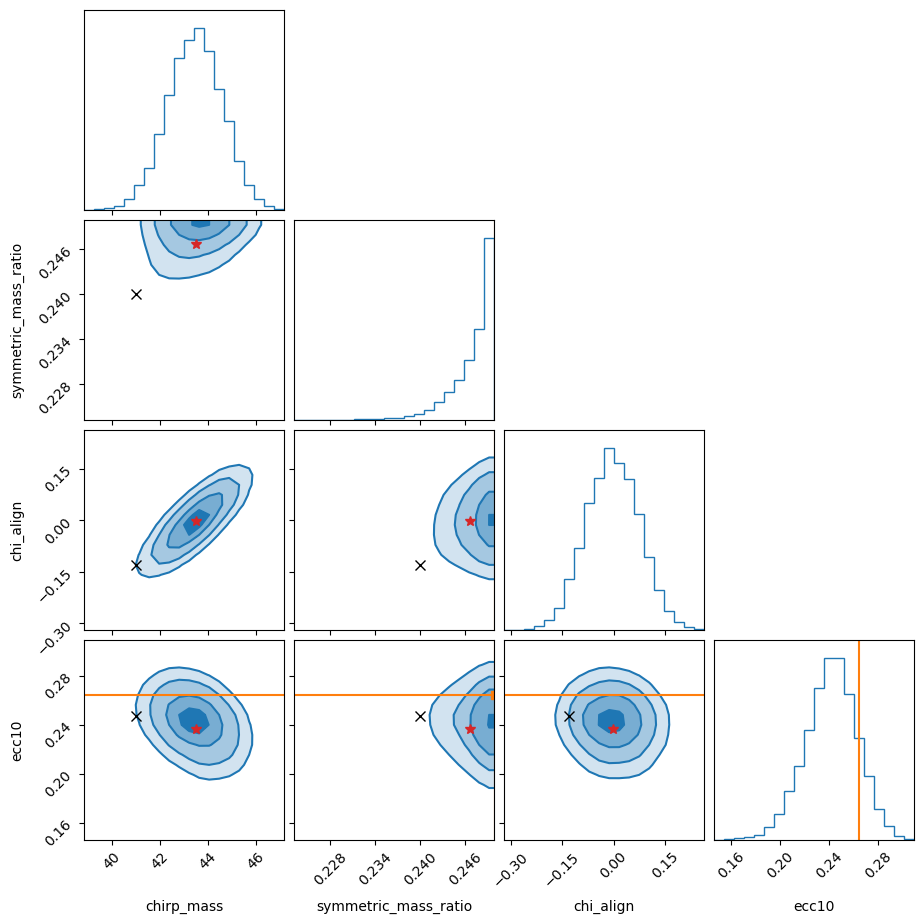

In [29]:
params = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10']
corner_samples = np.array([samples[key] for key in params]).T
corner_truths = [all_inj_params['posterior_samples'][par][0] for par in params]
fig = corner.corner(corner_samples, truths=corner_truths, color='C0', truth_color='C1', smooth=1, labels=params, plot_density=False, plot_datapoints=False, fill_contours=True)
old_params = [all_peak_params['posterior_samples'][par][0] for par in params]
corner.overplot_points(fig, [old_params], c='C3', label='old peak', marker='*', markersize=7)
delta_params_list = np.matmul(analysis_metric.normalized_evecs().samples, out.x)
delta_params = SimplePESamples(SamplesDict(analysis_metric.dx_directions, [[param] for param in delta_params_list]))
new_params = [delta_params[dx][0] + analysis_metric.x[dx][0] for dx in ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']]
new_params[-1] = np.sqrt(new_params[-1])
corner.overplot_points(fig, [new_params], c='k', label='new peak', marker='x', markersize=7)

In [30]:
all_inj_params['posterior_samples']['ecc10sqrd'] = [all_inj_params['posterior_samples']['ecc10'][0]**2]
inj_params_diff_old = [all_inj_params['posterior_samples'][par][0] - all_peak_params['posterior_samples'][par][0] for par in analysis_metric.dx_directions]
inj_dx_diff_old = np.matmul(np.linalg.inv(analysis_metric.normalized_evecs().samples), inj_params_diff_old)
dx_dist_old = np.sqrt(np.dot(inj_dx_diff_old, inj_dx_diff_old))
inj_dx_diff_new = np.array(inj_dx_diff_old) - np.array(out.x)
dx_dist_new = np.sqrt(np.dot(inj_dx_diff_new, inj_dx_diff_new))
print(f'Reduced dx distance from {dx_dist_old:.3f} to {dx_dist_new:.3f}')

Reduced dx distance from 2.462 to 1.840


In [27]:
all_inj_params

{'posterior_samples': {'21': [0.8729347065983498],
  '22': [20.892966634142084],
  '32': [1.3479616325227457],
  '33': [1.1269135642856574],
  '44': [2.064945857418369],
  'a_1': [0.4762272170423353],
  'a_2': [0.316969845163723],
  'alpha_net': [0.24112435223715473],
  'beta': [0.0],
  'chi_align': [-0.3972862805345721],
  'chi_eff': [-0.3971143487882235],
  'chi_p': [0.0],
  'chi_p_2spin': [0.0],
  'chirp_mass': [37.1942215134992],
  'chirp_mass_source': [33.34368565056427],
  'comoving_distance': [497.1208249458909],
  'comoving_volume': [514605565.8253358],
  'cos_iota': [-0.16249607572249708],
  'cos_theta_jn': [-0.16249607572249708],
  'cos_tilt_1': [-1.0],
  'cos_tilt_2': [-1.0],
  'dec': [-0.8333150497182571],
  'delta_t': [0.000244140625],
  'distance': [554.5284392647711],
  'ecc10': [0.2647390565386895],
  'ecc_harm_snr': [{'-1': 0.5851724009260396,
    '0': 20.73259379776953,
    '1': 7.447492157599886}],
  'ecc_harm_snr_imag': [{'-1': 0.5812284372827062,
    '0': 0.0,
    